### Probability Distribution Function

---

#### Import libraries

In [19]:
import pandas as pd
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.random import normal

---

### Probability Mass Function

##### 1. Rolling 1 die

In [2]:
L = []
for i in range(10000):
    L.append(random.randint(1,6))

In [3]:
print(len(L))
print(L[:5])

10000
[4, 5, 4, 2, 1]


<Axes: >

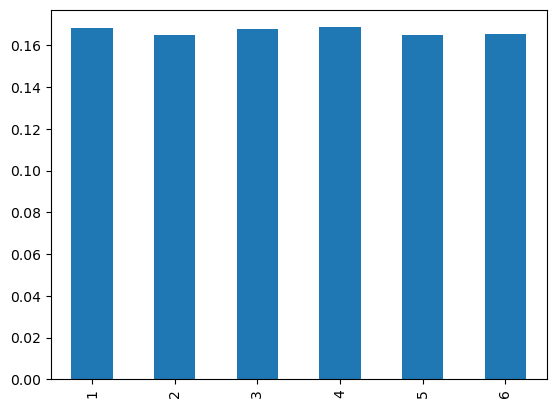

In [4]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()
s.plot(kind='bar')

##### 2. Rolling 2 die together

In [5]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [6]:
print(len(L))
print(L[:5])

10000
[4, 8, 4, 3, 10]


<Axes: >

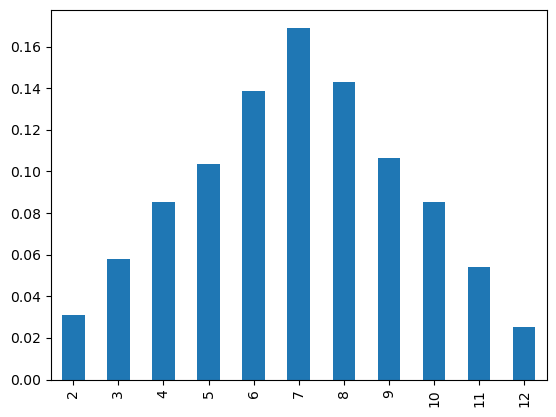

In [7]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()
s.plot(kind='bar')

##### 3. CDF (Cummalative Distribution Function) of PMF

<Axes: >

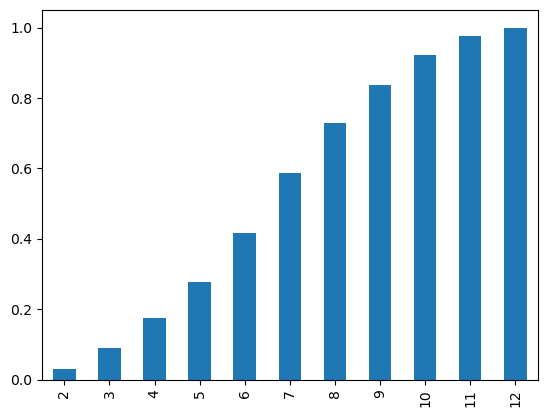

In [8]:
np.cumsum(s).plot(kind='bar')

---

### Probability/Parametric Density Estimation

In [10]:
sample = normal(loc=50, scale=5,size=1000)
sample.mean()

49.978312350070325

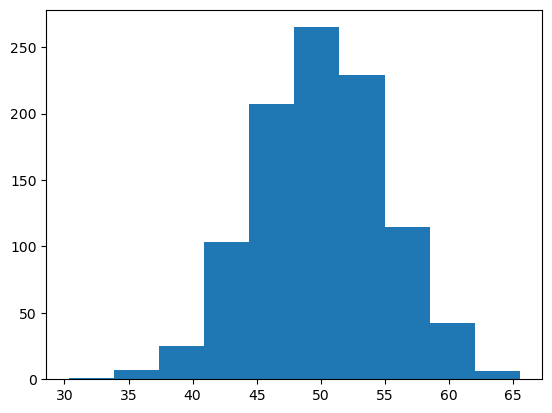

In [11]:
# plot histogram to understand the distribution of data
plt.hist(sample,bins=10)
plt.show()

In [15]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [16]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [17]:
values = np.linspace(sample.min(),sample.max(),100)
print(sample.max())
probabilities = [dist.pdf(value) for value in values]

65.51510675676134


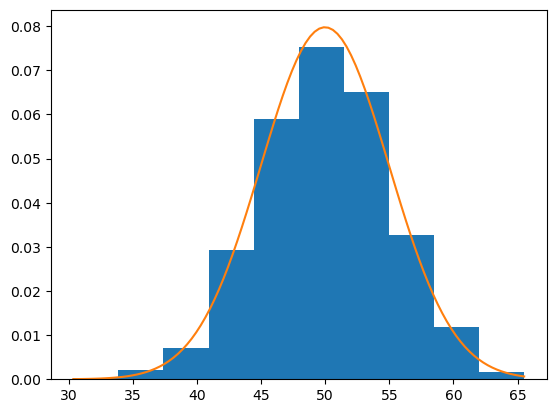

In [18]:
# plot the histogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

C:\Users\SESA702302\AppData\Local\Temp\ipykernel_2948\1950040031.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

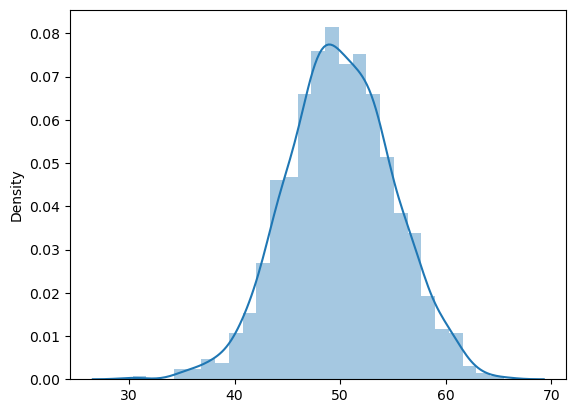

In [20]:
sns.distplot(sample)

---

### KDE

In [21]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [22]:
sample

array([21.09865386, 12.33254106, 17.76726346, 23.70603414, 21.91774688,
       14.57517913, 16.65230506, 14.91623117,  9.10285858, 19.3723836 ,
       18.42350472, 23.8925273 , 11.32370368, 22.81925463, 17.7217414 ,
       16.40006084, 15.95627257, 27.76180146, 26.70223381, 18.23979272,
       25.75175988, 22.21689928, 17.46693739, 16.93816137, 14.09446392,
       24.22479435, 25.94219673, 21.9308249 , 21.22465006, 20.20834158,
       22.66408427, 10.59571055, 16.07351915, 20.32983274, 21.51076415,
       23.92132704, 32.05768126, 28.54385467, 25.85135694, 13.588283  ,
       19.59687277, 11.15881366, 22.11517811,  9.25610981, 26.49999304,
       13.52313011, 18.18309575, 30.94538124, 19.27427607, 24.11472163,
        5.80101863, 23.31318633, 24.04000161, 17.72014775, 17.38637124,
       19.69936594, 17.64624737, 25.0266038 , 20.56665753, 11.04530078,
       15.74776913, 28.72353635, 28.18420362, 23.86556687, 16.03293598,
       12.18752594, 23.92581515,  9.64245716, 17.82104896, 18.06

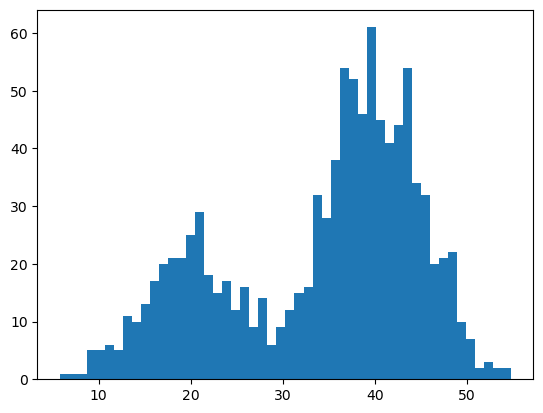

In [23]:
# plot histogram bins=50
plt.hist(sample,bins=50)
plt.show()

In [24]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=3, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=3)

In [25]:
values = np.linspace(sample.min(),sample.max(),1000)
values = values.reshape((len(values), 1))

In [26]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

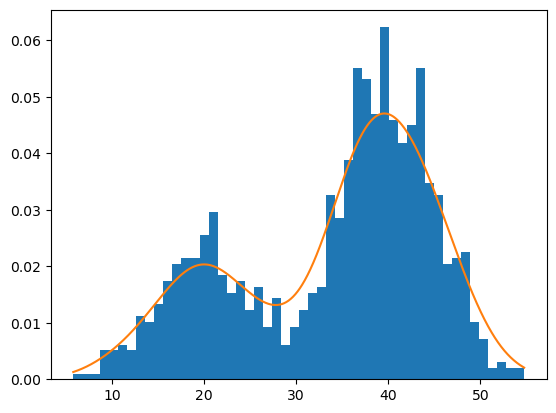

In [27]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

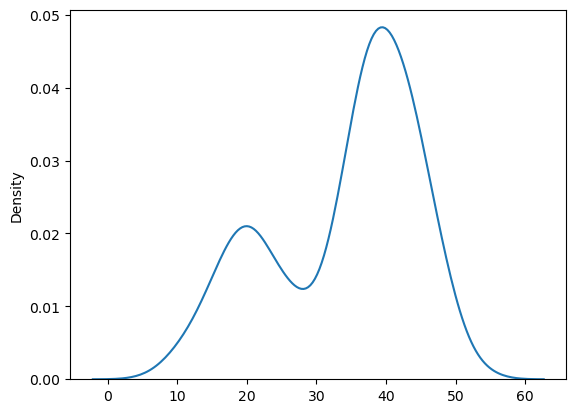

In [28]:
sns.kdeplot(sample.reshape(1000),bw_adjust=1)

---

In [50]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

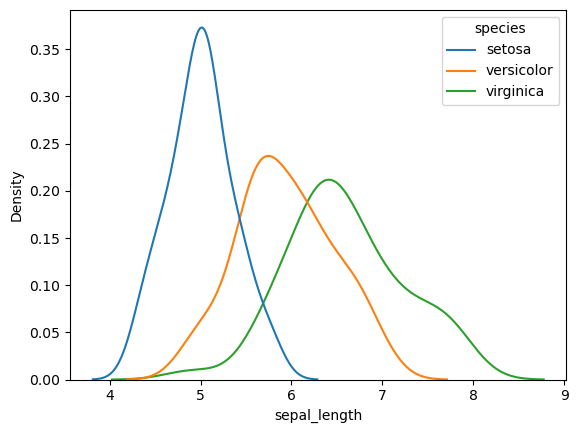

In [51]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

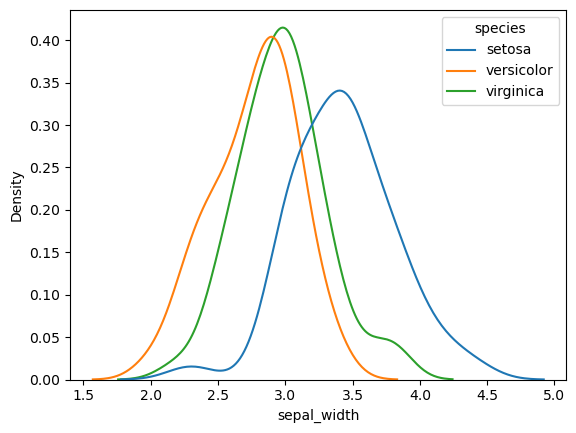

In [52]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

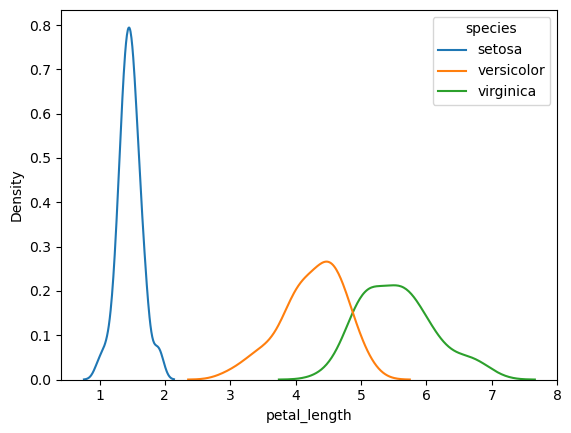

In [53]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

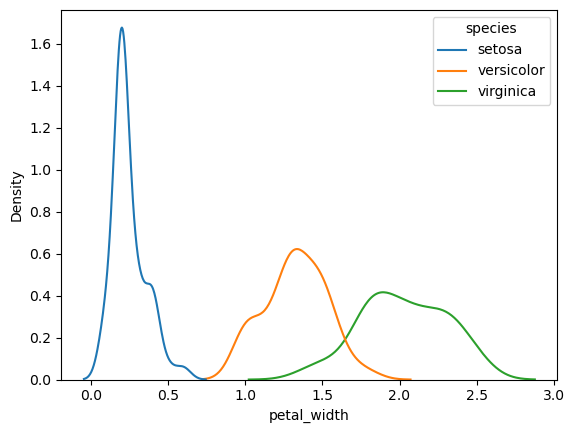

In [54]:
sns.kdeplot(data=df,x='petal_width',hue='species')

<AxesSubplot:xlabel='petal_width', ylabel='Density'>

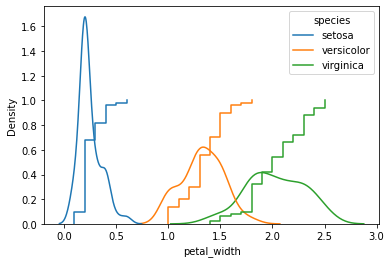

In [ ]:
sns.kdeplot(df['petal_width'],hue=df['species'])
sns.ecdfplot(data=df,x='petal_width',hue='species')

In [55]:
titanic = pd.read_csv(r'C:\Users\SESA702302\OneDrive - Schneider Electric\Personal\0.0 Data Science Personal\18. Descriptive Statistics - 2\2.0 Probability Distribution Function\titanic.csv')

In [56]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

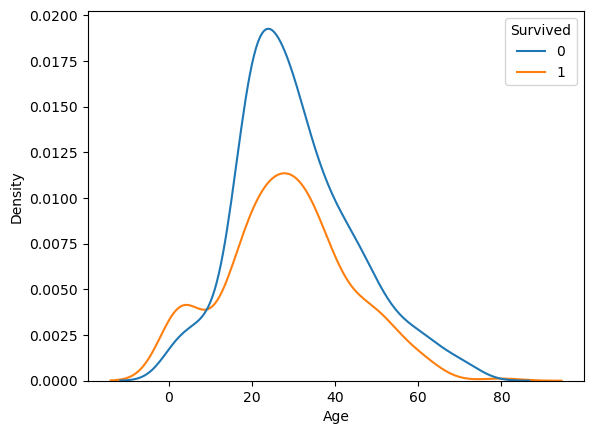

In [58]:
# code here
sns.kdeplot(data=titanic,x='Age',hue='Survived')

<Axes: xlabel='Age', ylabel='Density'>

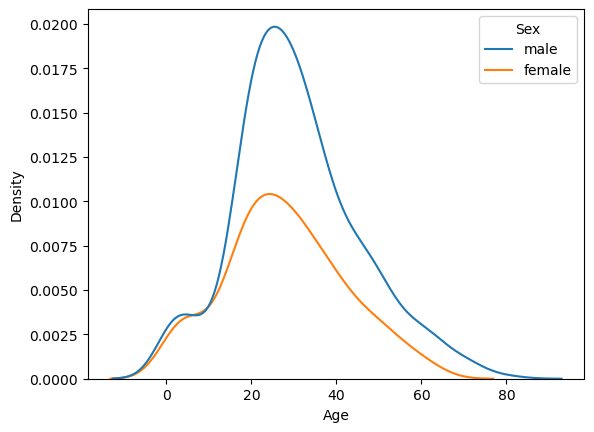

In [57]:
# code here
sns.kdeplot(data=titanic,x='Age',hue='Sex')

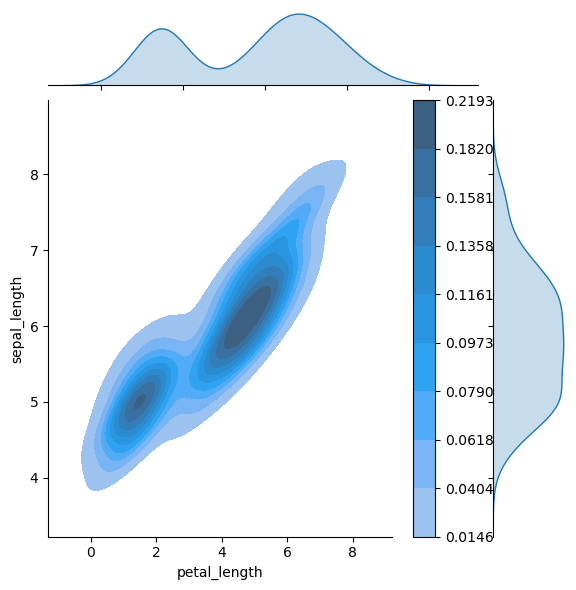

In [59]:
 sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde",fill=True,cbar=True)

<Axes: xlabel='Age', ylabel='Density'>

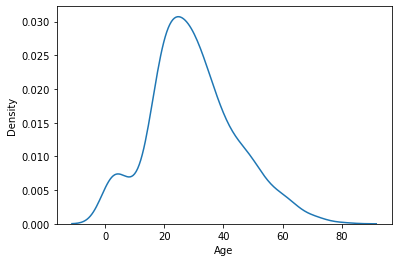

In [ ]:
sns.kdeplot(titanic['Age'])

<Axes: xlabel='Age', ylabel='Density'>

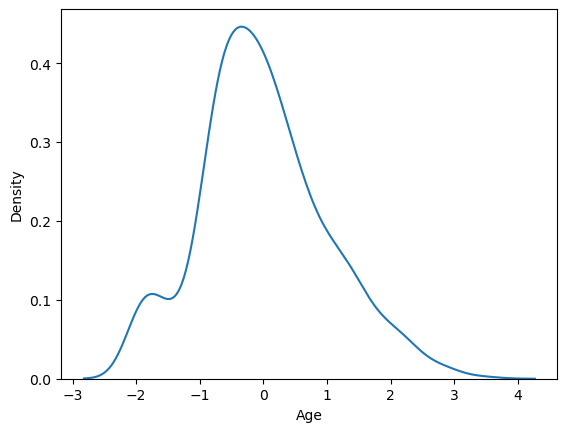

In [64]:
titanic['Age'].mean()
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()
sns.kdeplot(x)

In [67]:
titanic['Age'].skew()

0.38910778230082704

In [ ]:
titanic['Age'].mean() + 3*titanic['Age'].std()

73.27860964406094

In [ ]:
titanic['Age'].mean() - 3*titanic['Age'].std()

-13.880374349943303

In [ ]:
titanic[titanic['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [ ]:
titanic['Age'].max()

80.0